# 06 — Clustering
**Referencias:** ESL Cap. 14 (Unsupervised Learning) · Géron Cap. 9

## ¿Qué es clustering? (ESL 14.3)
Sin etiquetas, queremos encontrar **estructura latente** en los datos:
$$\min_{C_1,...,C_K} \sum_{k=1}^K \frac{1}{|C_k|} \sum_{i,j \in C_k} ||x_i - x_j||^2$$

Equivalente a minimizar la **within-cluster variance**.

In [8]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family':'Optima',
})
np.random.seed(42)

# Dataset: comportamiento de usuarios en fintech
n = 800
# 4 segmentos naturales
centers = [(2,2), (6,2), (2,7), (6,7)]
labels_true = np.random.choice(4, n)
X = np.array([centers[l] + np.random.randn(2)*0.9 for l in labels_true])

# Features más ricas para el ejemplo de negocio
n2 = 500
sessions       = np.random.randint(1, 50, n2).astype(float)
days_active    = np.random.randint(1, 90, n2).astype(float)
transactions   = np.random.randint(0, 30, n2).astype(float)
avg_txn_amount = np.abs(np.random.normal(100, 80, n2))
support_calls  = np.random.poisson(1, n2).astype(float)

# Inyectar segmentos reales
for i in range(n2):
    if sessions[i] > 30 and transactions[i] > 15:
        avg_txn_amount[i] += 200  # power users
    elif sessions[i] < 5:
        transactions[i] *= 0.1    # churned/inactive

users = pd.DataFrame({
    'sessions': sessions, 'days_active': days_active,
    'transactions': transactions, 'avg_txn_amount': avg_txn_amount,
    'support_calls': support_calls,
})

scaler = StandardScaler()
X_users = scaler.fit_transform(users)
print('Datos listos:', X_users.shape)

Datos listos: (500, 5)


## 1 — K-Means: elección de K (ESL 14.3.6)
El elbow method y el Silhouette score son los dos métodos principales.

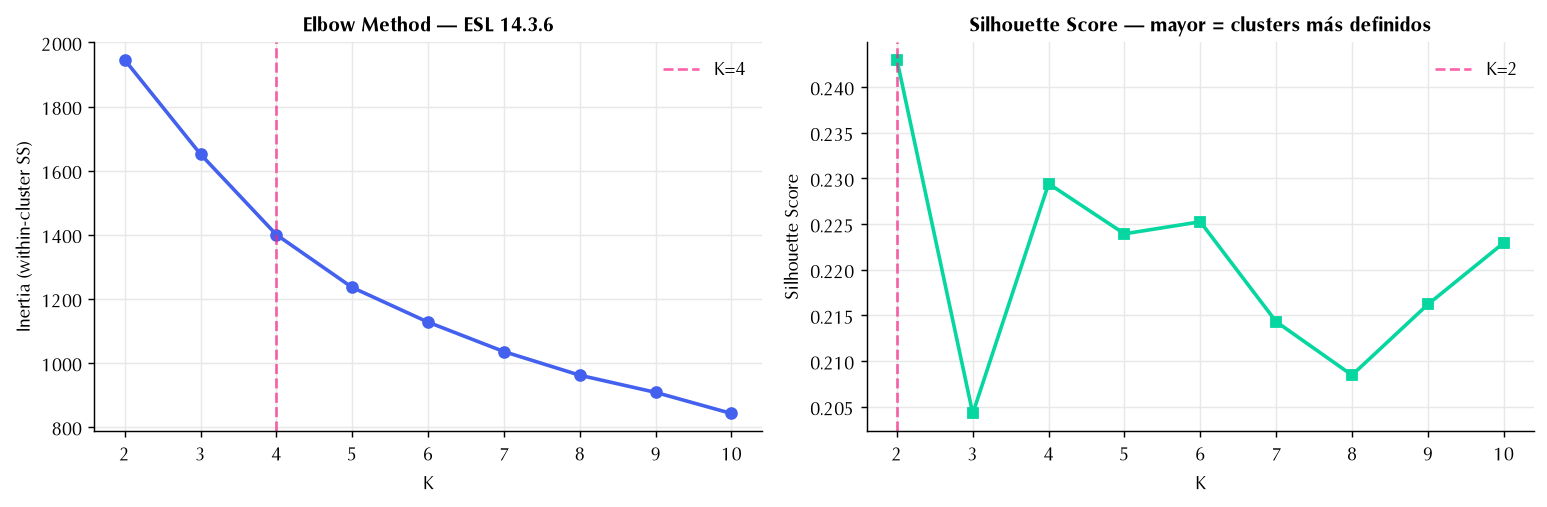

K óptimo por silhouette: 2


In [9]:
Ks = range(2, 11)
inertias, sils = [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_users)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_users, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(Ks), inertias, 'o-', color='#4361ee', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow Method — ESL 14.3.6')
# Marcar el codo
best_k_elbow = 4  # visual inspección
axes[0].axvline(best_k_elbow, color='#f72585', linestyle='--', alpha=0.7, label=f'K={best_k_elbow}')
axes[0].legend()

axes[1].plot(list(Ks), sils, 's-', color='#06d6a0', linewidth=2)
best_k_sil = list(Ks)[np.argmax(sils)]
axes[1].axvline(best_k_sil, color='#f72585', linestyle='--', alpha=0.7, label=f'K={best_k_sil}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — mayor = clusters más definidos')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'K óptimo por silhouette: {best_k_sil}')

## 2 — Silhouette Plot por sample (Géron Cap. 9)

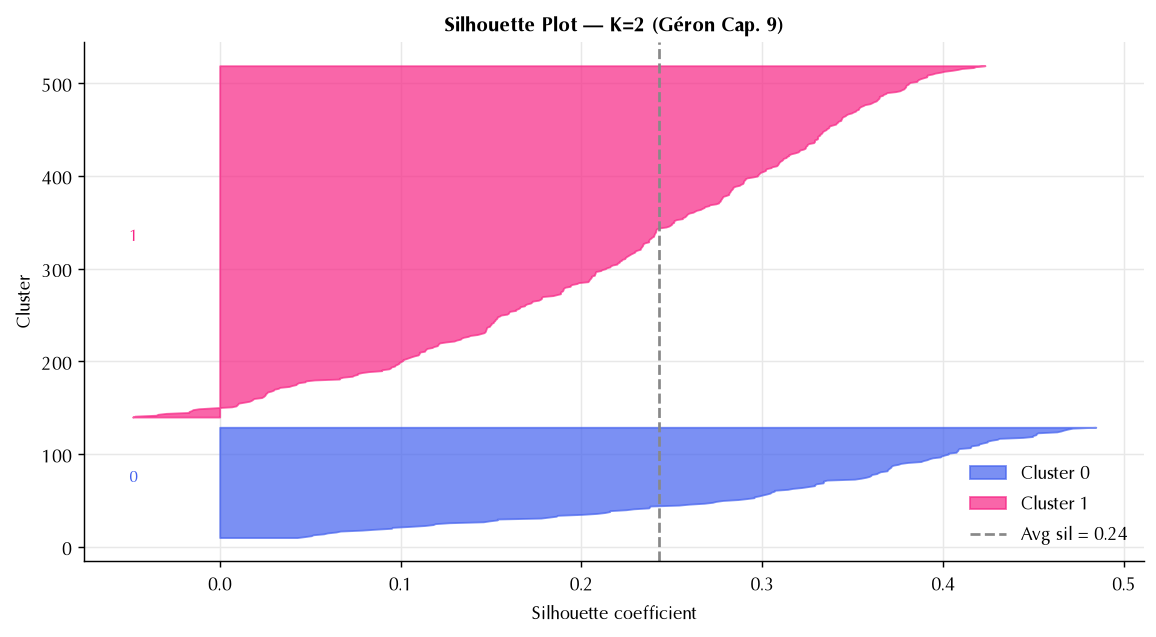

Clusters con coef < 0 → puntos mal asignados → considera otro K o DBSCAN


In [10]:
k = best_k_sil
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_users)

sil_vals = silhouette_samples(X_users, labels)
avg_sil  = sil_vals.mean()

COLORS = ['#4361ee','#f72585','#06d6a0','#ff9f1c','#7209b7']
fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in range(k):
    vals_i = np.sort(sil_vals[labels == i])
    size_i = len(vals_i)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                     alpha=0.7, color=COLORS[i % len(COLORS)], label=f'Cluster {i}')
    ax.text(-0.05, (y_lower + y_upper) / 2, str(i), fontsize=9, color=COLORS[i % len(COLORS)])
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='#888', linestyle='--', linewidth=1.5,
           label=f'Avg sil = {avg_sil:.2f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K={k} (Géron Cap. 9)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print('Clusters con coef < 0 → puntos mal asignados → considera otro K o DBSCAN')

## 3 — Gaussian Mixture Models: clustering probabilístico (ESL 14.3.7)
GMM ajusta una mezcla de gaussianas: $P(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x|\mu_k, \Sigma_k)$

Ventajas sobre K-Means:
- **Clusters elípticos** (no solo esféricos)
- **Probabilidades de pertenencia** en lugar de asignación dura
- **BIC/AIC** para seleccionar K

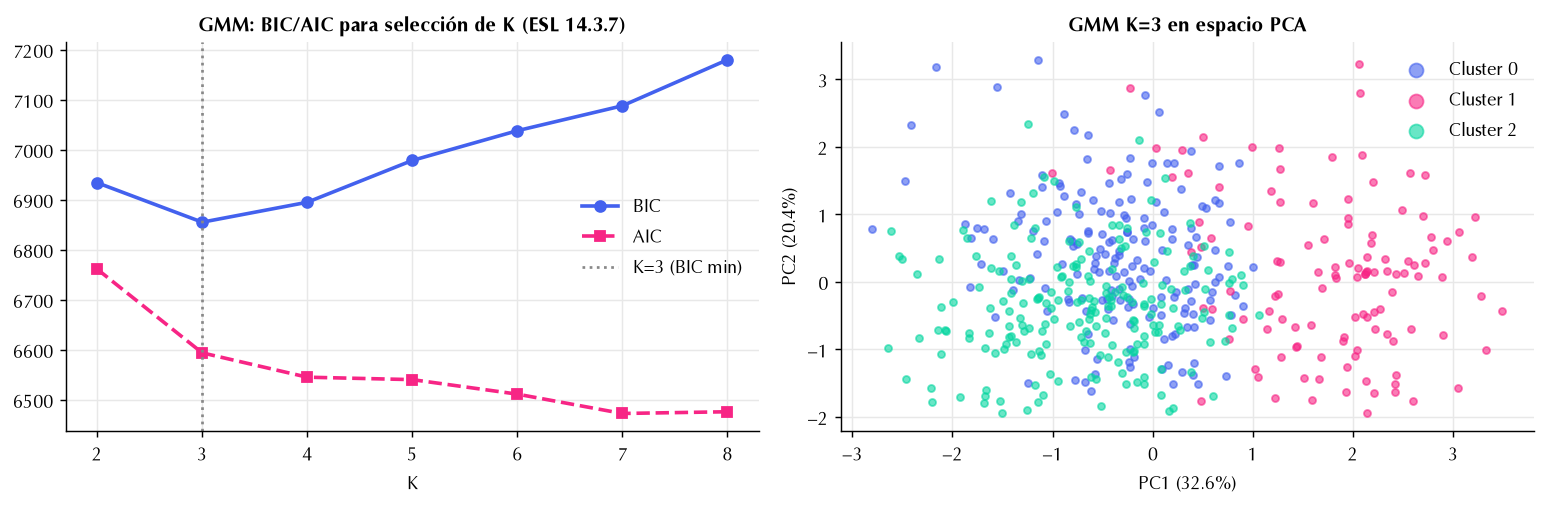

Usuarios ambiguos (prob < 0.7): 34 (6.8%)


In [11]:
# BIC para seleccionar K en GMM (ESL 14.3.7)
Ks_gmm = range(2, 9)
bic_scores, aic_scores = [], []

for k in Ks_gmm:
    gm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gm.fit(X_users)
    bic_scores.append(gm.bic(X_users))
    aic_scores.append(gm.aic(X_users))

best_k_bic = list(Ks_gmm)[np.argmin(bic_scores)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(Ks_gmm), bic_scores, 'o-', color='#4361ee', linewidth=2, label='BIC')
axes[0].plot(list(Ks_gmm), aic_scores, 's--', color='#f72585', linewidth=2, label='AIC')
axes[0].axvline(best_k_bic, color='#888', linestyle=':', label=f'K={best_k_bic} (BIC min)')
axes[0].set_xlabel('K'); axes[0].set_title('GMM: BIC/AIC para selección de K (ESL 14.3.7)')
axes[0].legend()

# Clusters y sus probabilidades
gm_best = GaussianMixture(n_components=best_k_bic, random_state=42, n_init=3)
gm_best.fit(X_users)
probs = gm_best.predict_proba(X_users)
labels_gmm = gm_best.predict(X_users)

# Visualizar en 2D via PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_users)
for i in range(best_k_bic):
    mask = labels_gmm == i
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=15, alpha=0.6, color=COLORS[i % len(COLORS)], label=f'Cluster {i}')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title(f'GMM K={best_k_bic} en espacio PCA')
axes[1].legend(markerscale=2)
plt.tight_layout()
plt.show()

# Incertidumbre: usuarios con probabilidad < 0.7 para su cluster
max_prob = probs.max(axis=1)
uncertain = (max_prob < 0.7).sum()
print(f'Usuarios ambiguos (prob < 0.7): {uncertain} ({uncertain/len(users):.1%})')

## 4 — Clustering jerárquico y dendrograma (ESL 14.3.12 / Géron Cap. 9)

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_12587/974296511.py:32: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Optima.
  plt.tight_layout()
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Optima.
  fig.canvas.print_figure(bytes_io, **kw)


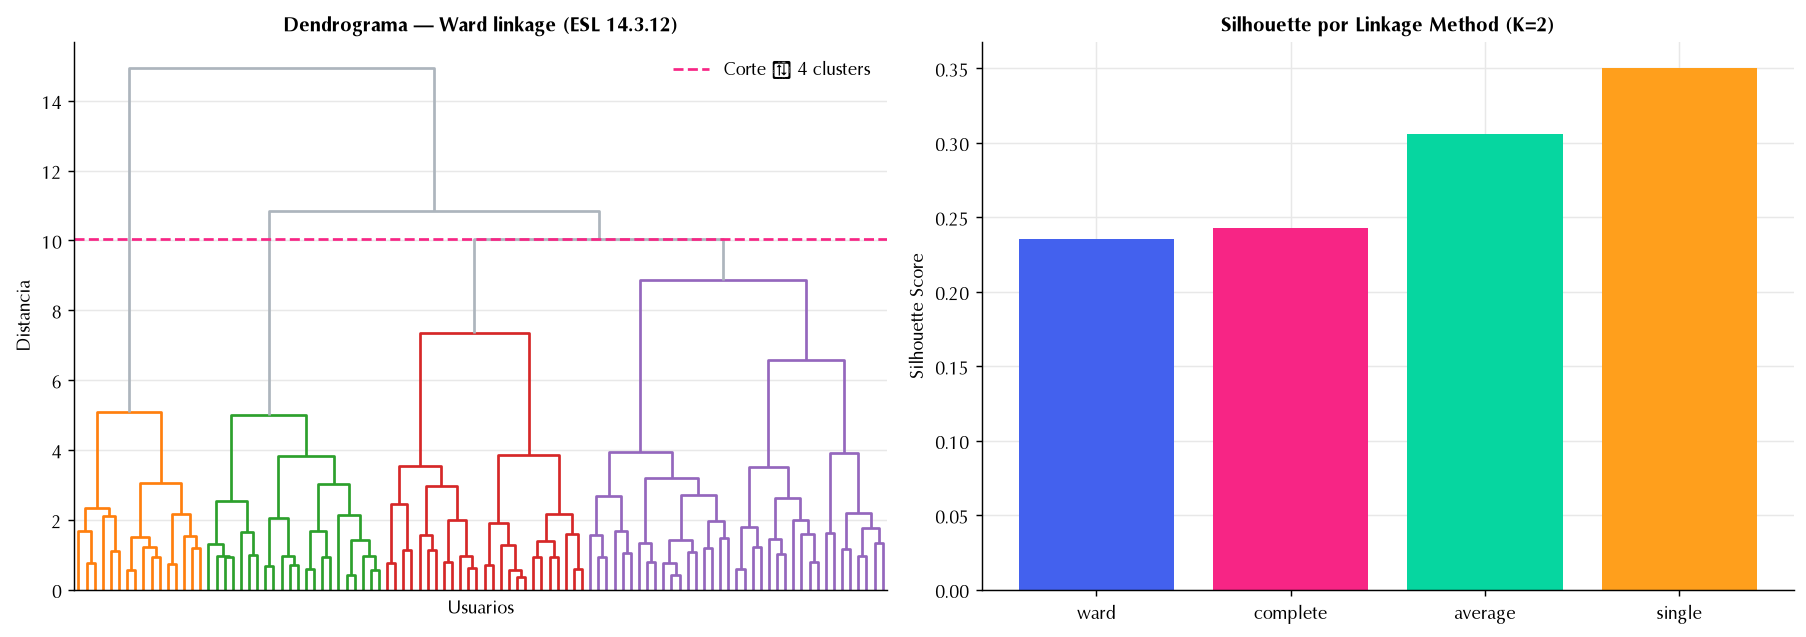

Mejor linkage: single (sil=0.350)


In [12]:
# Dendrograma sobre muestra pequeña para legibilidad
idx = np.random.choice(len(X_users), 100, replace=False)
X_sample = X_users[idx]

Z = linkage(X_sample, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrograma
dendrogram(Z, ax=axes[0], no_labels=True,
           color_threshold=Z[-3, 2],  # cortar a 4-5 clusters
           above_threshold_color='#adb5bd')
axes[0].axhline(Z[-3, 2], color='#f72585', linestyle='--', linewidth=1.5,
                label=f'Corte → {4} clusters')
axes[0].set_title('Dendrograma — Ward linkage (ESL 14.3.12)')
axes[0].set_xlabel('Usuarios'); axes[0].set_ylabel('Distancia')
axes[0].legend()

# Comparar linkage methods
methods = ['ward','complete','average','single']
sil_by_method = {}
for method in methods:
    ac = AgglomerativeClustering(n_clusters=best_k_sil, linkage=method)
    lbl = ac.fit_predict(X_users)
    sil_by_method[method] = silhouette_score(X_users, lbl)

axes[1].bar(sil_by_method.keys(), sil_by_method.values(),
            color=['#4361ee','#f72585','#06d6a0','#ff9f1c'])
axes[1].set_title(f'Silhouette por Linkage Method (K={best_k_sil})')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()
best_method = max(sil_by_method, key=sil_by_method.get)
print(f'Mejor linkage: {best_method} (sil={sil_by_method[best_method]:.3f})')

## 5 — DBSCAN: clusters de forma arbitraria (Géron Cap. 9)
DBSCAN detecta **noise points** y no requiere especificar K.

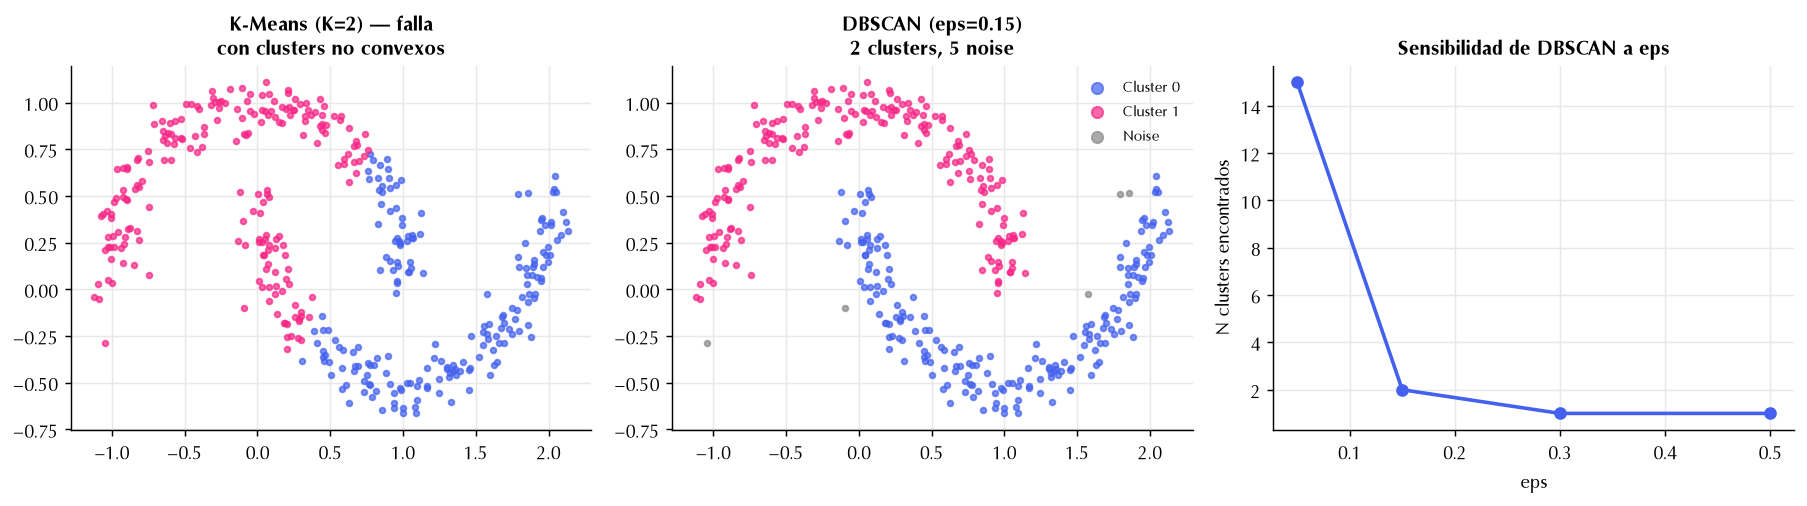

In [13]:
# Crear datos con forma arbitraria y ruido
from sklearn.datasets import make_moons
X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# K-Means: falla con formas no convexas
km_moons = KMeans(n_clusters=2, random_state=42, n_init=5)
km_labels = km_moons.fit_predict(X_moons)
for i in range(2):
    mask = km_labels == i
    axes[0].scatter(X_moons[mask,0], X_moons[mask,1], s=10, alpha=0.7, color=COLORS[i])
axes[0].set_title('K-Means (K=2) — falla\ncon clusters no convexos')

# DBSCAN
db = DBSCAN(eps=0.15, min_samples=5)
db_labels = db.fit_predict(X_moons)
unique_labels = set(db_labels)
for l in unique_labels:
    mask = db_labels == l
    color = '#888' if l == -1 else COLORS[l % len(COLORS)]
    label = 'Noise' if l == -1 else f'Cluster {l}'
    axes[1].scatter(X_moons[mask,0], X_moons[mask,1], s=10, alpha=0.7, color=color, label=label)
axes[1].set_title(f'DBSCAN (eps=0.15)\n{len(unique_labels)-1} clusters, {(db_labels==-1).sum()} noise')
axes[1].legend(markerscale=2, fontsize=8)

# Comparar eps
eps_vals = [0.05, 0.15, 0.3, 0.5]
n_clusters_eps = []
for eps in eps_vals:
    lbl = DBSCAN(eps=eps, min_samples=5).fit_predict(X_moons)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_clusters_eps.append(n_cl)
    
axes[2].plot(eps_vals, n_clusters_eps, 'o-', color='#4361ee', linewidth=2)
axes[2].set_xlabel('eps'); axes[2].set_ylabel('N clusters encontrados')
axes[2].set_title('Sensibilidad de DBSCAN a eps')

plt.tight_layout()
plt.show()

## 6 — Interpretación de clusters para negocio

Perfil de clusters:
         sessions  days_active  transactions  avg_txn_amount  support_calls  n_users   pct
cluster                                                                                   
0            15.2         45.8          18.9           110.1            1.2      180  36.0
1            38.6         47.9          20.9           286.8            1.1      118  23.6
2            26.7         45.6           5.8            90.4            0.7      202  40.4


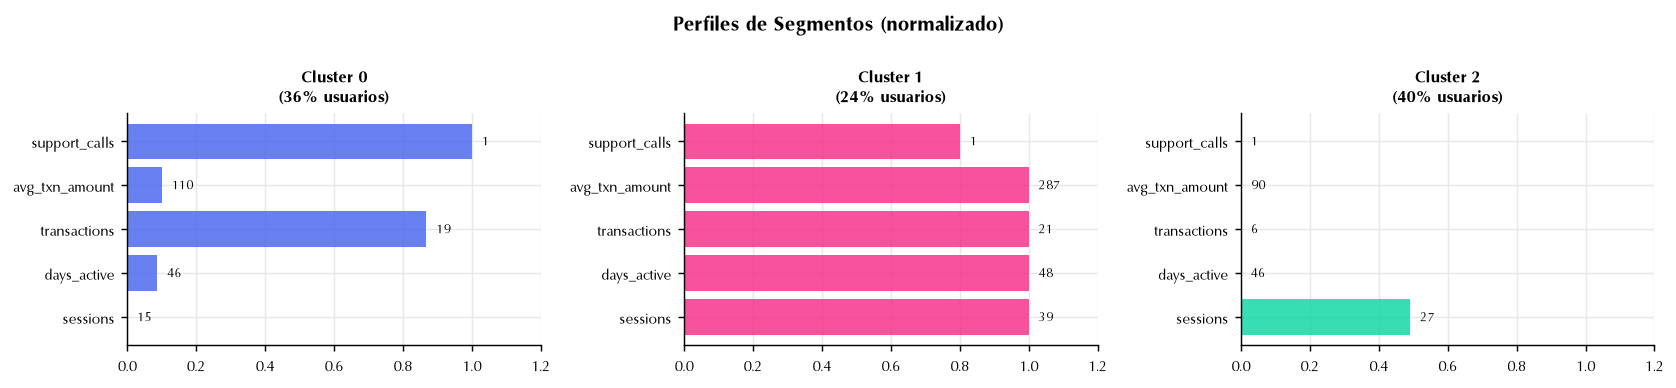

In [14]:
users['cluster'] = labels_gmm

# Perfil por cluster
profile = users.groupby('cluster').agg({
    'sessions':        'mean',
    'days_active':     'mean',
    'transactions':    'mean',
    'avg_txn_amount':  'mean',
    'support_calls':   'mean',
}).round(1)
profile['n_users'] = users.groupby('cluster').size()
profile['pct'] = (profile['n_users'] / len(users) * 100).round(1)
print('Perfil de clusters:')
print(profile.to_string())

# Normalizar para spider/radar
features_plot = ['sessions','days_active','transactions','avg_txn_amount','support_calls']
prof_norm = profile[features_plot].apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9))

fig, axes = plt.subplots(1, len(profile), figsize=(13, 3))
for i, (cluster_id, row) in enumerate(prof_norm.iterrows()):
    axes[i].barh(features_plot, row.values, color=COLORS[i % len(COLORS)], alpha=0.8)
    axes[i].set_xlim(0, 1.2)
    axes[i].set_title(f'Cluster {cluster_id}\n({profile.loc[cluster_id,"pct"]:.0f}% usuarios)', fontsize=9)
    axes[i].tick_params(labelsize=8)
    for j, v in enumerate(row.values):
        axes[i].text(v + 0.03, j, f'{profile.loc[cluster_id, features_plot[j]]:.0f}',
                     va='center', fontsize=7)

plt.suptitle('Perfiles de Segmentos (normalizado)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Resumen

| Algoritmo | Fortaleza | Limitación | Referencia |
|---|---|---|---|
| K-Means | Rápido, escala | Solo clusters esféricos, K fijo | ESL 14.3 |
| GMM | Elíptico, probabilístico, BIC para K | Asume distribución gaussiana | ESL 14.3.7 |
| Jerárquico | Dendrograma, no requiere K a priori | $O(n^2)$ memoria | ESL 14.3.12 |
| DBSCAN | Formas arbitrarias, detecta ruido | Sensible a eps y min_samples | Géron Cap. 9 |

**Siguiente:** `07_dimensionality_reduction.ipynb`